# Using the models to indicate whether the vault songs are true to their origin

With Big Machine Records selling master recordings of her first albums (up until *reputation*) Swift decided to rerecord lost songs. With those songs she decided to record some new songs that were sitting "in the vault". The reasoning differs on why those songs weren't included in the first place, *Message In A Bottle* was considered too pop for the album *Red*, *Nothing New* was replaced with a softer message of *The Lucky One* or *Is It Over Now?* while being a cult-classic now, was too wordy for a concise *1989*. Using the models we can see if the "new Taylor" bled through into those old tracks. Even though words were written years ago, the new sound/production makes some of them sound more modern they would have been more than a decade ago. For those interested, Swift bought back her masters in 2025 and the rerecordings have stopped since then, with fans still waiting for the missing debut and *reputation* vault tracks.

In [25]:
import pandas as pd
from pathlib import Path
from tensorflow.keras.models import load_model
import os
import joblib
import matplotlib.pyplot as plt
import re
import seaborn as sns
import re
from adjustText import adjust_text

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [64]:
%store -r features
%store -r album_dict

In [78]:
data_dir = Path("data")
input_path = Path("..") / data_dir / "taylor_swift_spotify.csv"
graph_dir = Path("graphs")

songs = pd.read_csv(input_path)

In [4]:
tv_albums = list(songs[songs["album"].str.contains("Taylor's Version")]["album"].unique())
tv_albums.remove("1989 (Taylor's Version)")
rerecordings = songs[songs["album"].isin(tv_albums)].copy()

In [6]:
rerecordings.loc[:, "short_album_name"] = rerecordings["album"].replace(album_dict)
rerecordings.loc[:, "clean_name"] = rerecordings["name"].replace(r"\s*\(Taylor.*$", "", regex=True).str.strip()

In [7]:
vault = rerecordings[rerecordings["name"].str.contains("(From The Vault)", regex=False)].copy()

## Neural Network

In [8]:
model_dir = Path("models")
model_path = Path(f"../{model_dir}/new_taylor_NN.keras")
scaler_path = Path(f"../{model_dir}/scaler_NN.joblib")

neural_network = load_model(model_path)
scaler = joblib.load(scaler_path)

In [9]:
neural_network.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape         ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ dense_9 (Dense)             │ (None, 32)           │         256 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ dense_10 (Dense)            │ (None, 16)           │         528 │
├─────────────────────────────┼──────────────────────┼─────────────┤
│ dense_11 (Dense)            │ (None, 1)            │          17 │
└─────────────────────────────┴──────────────────────┴─────────────┘

 Total params: 2,405 (9.40 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,604 (6.27 KB)

In [10]:
X = vault[features].values
X_scaled = scaler.transform(X)

probs = neural_network.predict(X_scaled)
pred = probs > 0.5

vault.loc[:, "probability"] = probs
vault.loc[:, "is_new_taylor"] = pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


In [14]:
display(vault[["clean_name", "short_album_name", "probability", "is_new_taylor"]].sort_values("probability", ascending=False).head())

,clean_name,short_album_name,probability,is_new_taylor
63,"""Slut!""",1989,0.889003,True
220,We Were Happy,fearless,0.859400,True
222,Don’t You,fearless,0.855753,True
190,Nothing New (feat. Phoebe Bridgers),red,0.830262,True
65,Now That We Don't Talk,1989,0.809275,True


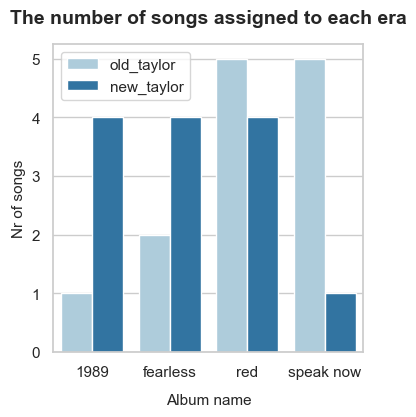

In [83]:
sns.set_theme(style="whitegrid", font="sans-serif")

counts = (
    vault.groupby(["short_album_name", "is_new_taylor"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(4, 4))
ax = sns.barplot(x="short_album_name",
            y="count", 
            hue="is_new_taylor", 
            data=counts,
           palette="Paired")

ax.set_title(
    "The number of songs assigned to each era",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Album name", fontsize=11, labelpad=10)
ax.set_ylabel("Nr of songs", fontsize=11)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['old_taylor', 'new_taylor'])

plt.savefig(f"{graph_dir}/NN_barplot.png")
plt.show()

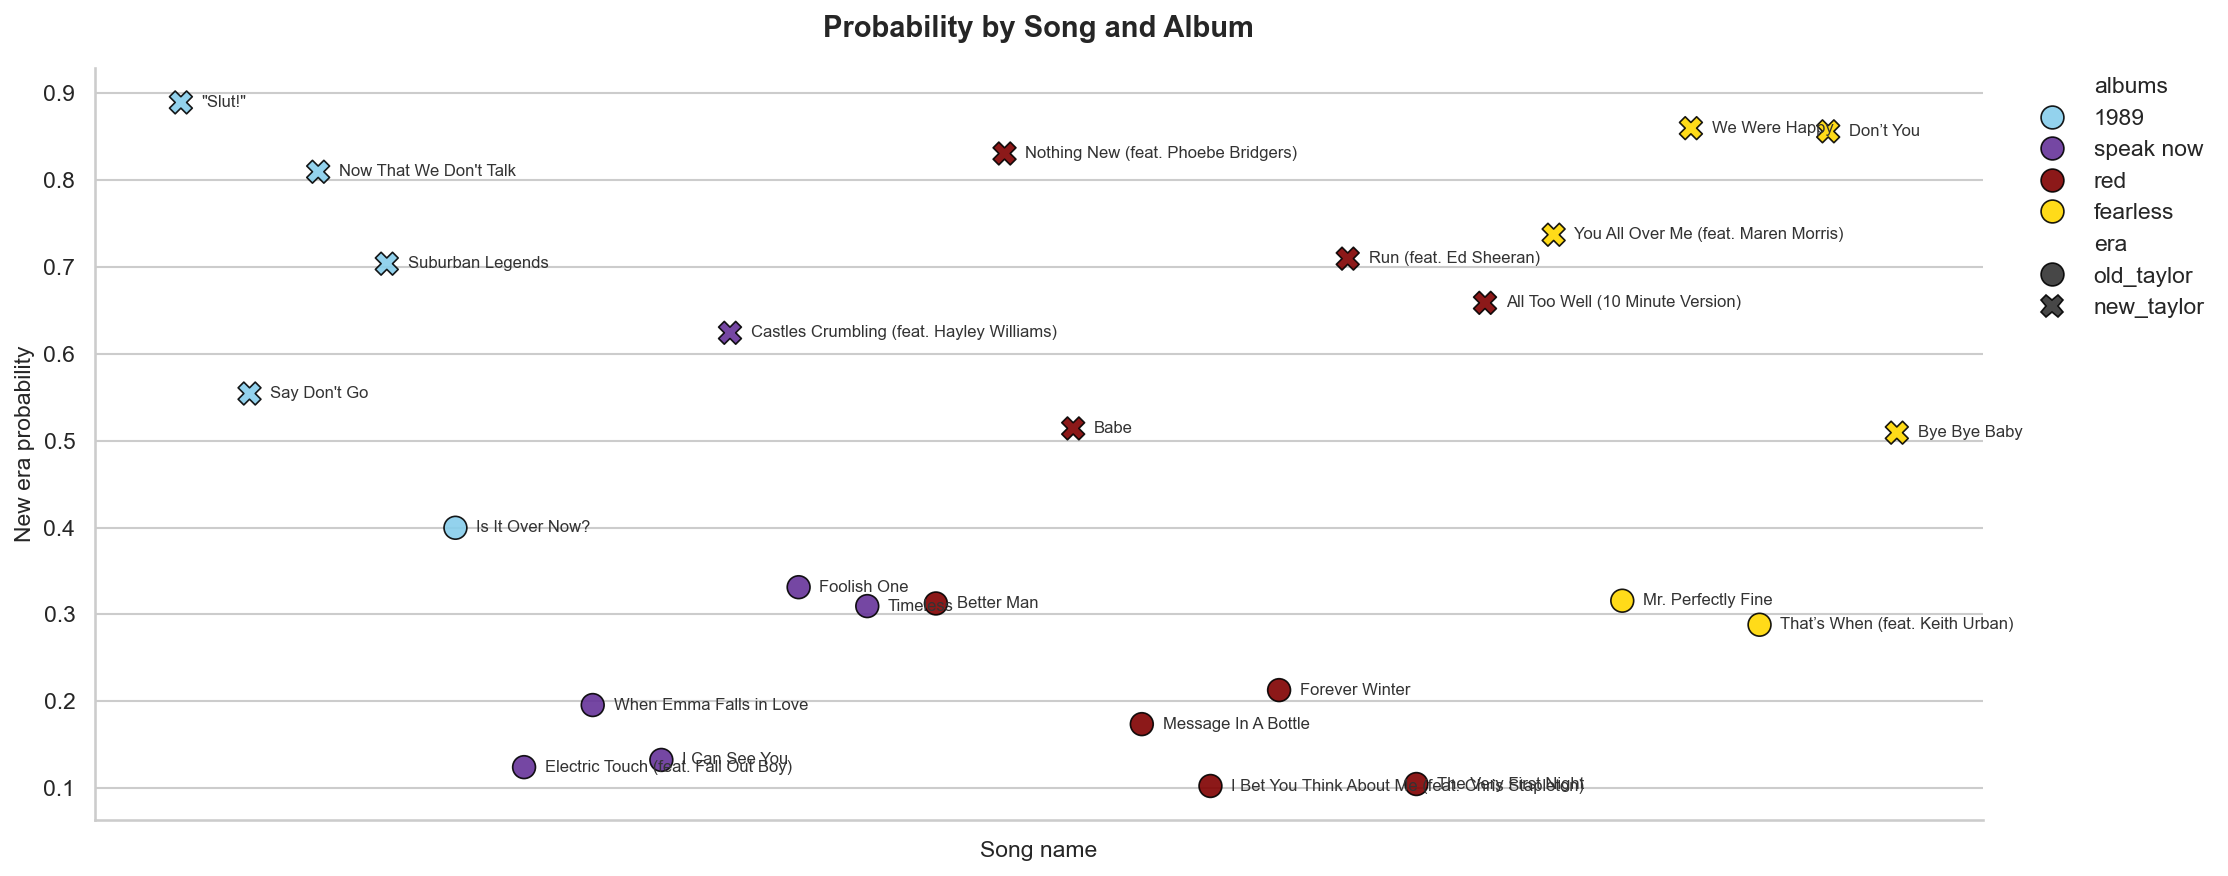

In [84]:
plt.figure(figsize=(15, 6), dpi=150)

colors = ['skyblue', 'rebeccapurple', 'maroon',
          'gold']

custom_palette = sns.color_palette(colors)

ax = sns.scatterplot(
    data=vault,
    x="clean_name",
    y="probability",
    hue="short_album_name",
    style="is_new_taylor",
    s=120,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.8,
    palette=custom_palette
)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['albums', '1989', 'speak now', 'red', 'fearless', 'era', 'old_taylor', 'new_taylor'])

sns.move_legend(
    ax,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False,
)

for i in range(vault.shape[0]):
    row = vault.iloc[i]
    ax.annotate(
        text=row["clean_name"], 
        xy=(row["clean_name"], row["probability"]),
        xytext=(
            10,
            0,
        ), 
        textcoords="offset points",
        fontsize=8,
        va="center",
        color="#333333",
    )

ax.set_xticks([])

plt.title(
    "Probability by Song and Album", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Song name", fontsize=11, labelpad=10)
plt.ylabel("New era probability", fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig(f"{graph_dir}/NN_songs_scatterplot.png")
plt.show()

From the graphs it's easy to say that *Speak Now* Vault is the most "old Taylor" and *1989* is the most "new Taylor". While it's not surprising that songs such as *"Slut!"* and *Nothing New* take the top spots in most like the newer era, it's surprising to see *We Were Happy* and *Don't You*. Those not-so-liked and not-so-popular ballads have not been as cherished by the fans quite as much as, for example, *Mr Perfectly Fine* that is securely an "old Taylor" song. Possibly the *Fearless* writing doesn't go well with the newer sound? The top spot for the old era is *I Bet You Think About Me* and it is no surprise for anyone who has heard the song. While the album *Red* is a blend of country and pop, *I Bet You Think About Me* is 100% country and while a bit more mature it could fit even onto debut. 

# KNN

In [48]:
knn_model_path = Path(f"../{model_dir}/knn_model.joblib")
knn = joblib.load(knn_model_path)

In [58]:
knn_pred = knn.predict(X_scaled)
vault.loc[:, "knn_is_new_taylor"] = knn_pred

In [63]:
display(vault[["clean_name", "short_album_name", "is_new_taylor", "knn_is_new_taylor"]]
        [vault["is_new_taylor"] != vault["knn_is_new_taylor"]])

,clean_name,short_album_name,is_new_taylor,knn_is_new_taylor
64,Say Don't Go,1989,True,False
109,Castles Crumbling (feat. Hayley Williams),speak now,True,False
110,Foolish One,speak now,False,True
197,All Too Well (10 Minute Version),red,True,False
223,Bye Bye Baby,fearless,True,False


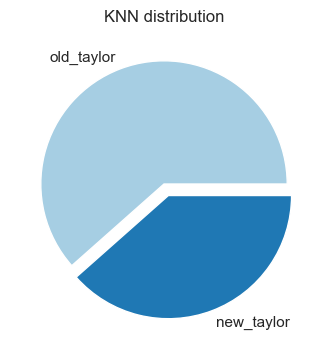

In [85]:
counts = (
    vault.groupby(["knn_is_new_taylor"])
    .size()
    .reset_index(name="count")
)

explode = [0, 0.1]

plt.figure(figsize=(4, 4))
plt.pie(
    x=counts["count"],
    labels=["old_taylor", "new_taylor"],
    colors=sns.color_palette("Paired"),
    explode=explode,
)
plt.title("KNN distribution")
plt.savefig(f"{graph_dir}/KNN_piechart.png")
plt.show()

Interestingly the KNN model and the Neural Network had almost the exact same answers, except 5 songs. Out of 4 which were "incorrectly" marked by the Neural Network and "correctly" marked by the KNN, if we consider the vault as part of the old era.

# Summary

In this project I created two Machine Learning models that distinguish between the different musical eras of Taylor Swift's career. Both of the models had high precision and high recall with the Neural Network significantly outperforming the KNN model. The experiment ended with checking how songs "From The Vault", written years ago, but released recently, place in the discography. Neural Network gave us an even split between new/old, while KNN decided that the vault tracks are closer to the country roots. Two standout songs are *"Slut!"* and *I Bet You Think About Me* as sitting on the opposite of the spectrum.